# 02 - Temporal Exploratory Data Analysis (EDA)
## What this notebook does
This notebook quantifies the patterns between electricity prices and the temporal variables: hours, weeks, month, and year. For each variable, we examine the price formation, dependencies, distribution characteristics, and statistical properties that will guide feature engineering and forecasting model selection.

Accurate day-ahead electricity price forecasting supports energy trading, grid balancing, industrial scheduling, and renewable integration.

## Key questions
- What is the distribution of day-ahead electricity price
- What is the temporal patterns of day-ahead electricity price

## Data 
Loaded from "data/processed/df_alls_cleaned.parquet" (produced by "01_data_processing.ipynb")

## Distribution of Prices

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sys.path.append("../src")
import style 
style.apply_style()

pd.set_option("display.max_columns", 50)

In [3]:
df_alls = pd.read_parquet("../data/processed/df_alls_cleaned.parquet")

In [4]:
df_alls.head()

,MTU (CET/CEST),Area,Day-ahead Price (EUR/MWh),Actual Total Load (MW)_load,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_offshore,Intraday (MW)_wind_offshore,Current (MW)_wind_offshore,Actual (MW)_wind_offshore,Day-ahead (MW)_wind_onshore,Intraday (MW)_wind_onshore,Current (MW)_wind_onshore,Actual (MW)_wind_onshore,Day-ahead (MW)_solar,Intraday (MW)_solar,Current (MW)_solar,Actual (MW)_solar
timestamp,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00+01:00,01/01/2016 00:00:00 - 01/01/2016 01:00:00,BZN|FR,23.86,58639.0,58600.0,0.0,NaN,NaN,NaN,2313.42,NaN,NaN,2189.0,0.0,NaN,NaN,0.0
2016-01-01 01:00:00+01:00,01/01/2016 01:00:00 - 01/01/2016 02:00:00,BZN|FR,22.39,56733.0,56550.0,0.0,NaN,NaN,NaN,2003.04,NaN,NaN,1753.0,0.0,NaN,NaN,0.0
2016-01-01 02:00:00+01:00,01/01/2016 02:00:00 - 01/01/2016 03:00:00,BZN|FR,20.59,55127.0,56150.0,0.0,NaN,NaN,NaN,1743.72,NaN,NaN,1430.0,0.0,NaN,NaN,0.0
2016-01-01 03:00:00+01:00,01/01/2016 03:00:00 - 01/01/2016 04:00:00,BZN|FR,16.81,51744.0,52600.0,0.0,NaN,NaN,NaN,1490.09,NaN,NaN,1214.0,0.0,NaN,NaN,0.0
2016-01-01 04:00:00+01:00,01/01/2016 04:00:00 - 01/01/2016 05:00:00,BZN|FR,17.41,51744.0,49750.0,0.0,NaN,NaN,NaN,1238.09,NaN,NaN,1031.0,0.0,NaN,NaN,0.0


In [5]:
df_alls["Day-ahead Price (EUR/MWh)"].describe()

count    78912.000000
mean        82.573143
std         95.270461
min       -134.940000
25%         33.000000
50%         50.000000
75%         89.920000
max       2987.780000
Name: Day-ahead Price (EUR/MWh), dtype: float64

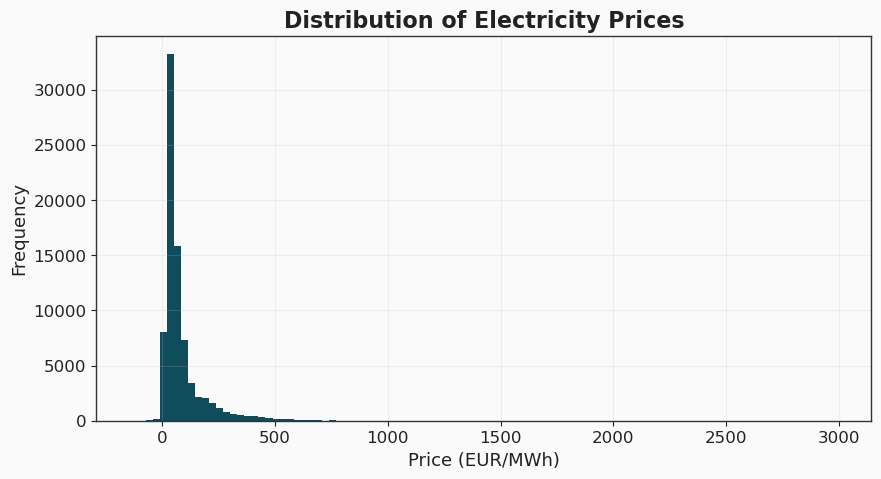

In [6]:
plt.figure()
df_alls["Day-ahead Price (EUR/MWh)"].hist(bins = 100, color = style.COLORS["primary"])
plt.title("Distribution of Electricity Prices")
plt.xlabel("Price (EUR/MWh)")
plt.ylabel("Frequency")
plt.savefig("../reports/figures/Distribution_of_Electricity_Prices.png")
plt.show()

Electricity prices show a right-skewed distribution. The price mean is 83 EUR/MWh, price median is 50 EUR/MWh, minimum price is -135 EUR/MWh. The maximum price 2988 EUR/MWh and its distance from the upper quantile indicates the occasional extreme price spikes. The extreme right-skewness will bias the modelling and careful handelling of error matrics is required. 

### Hourly Patterns

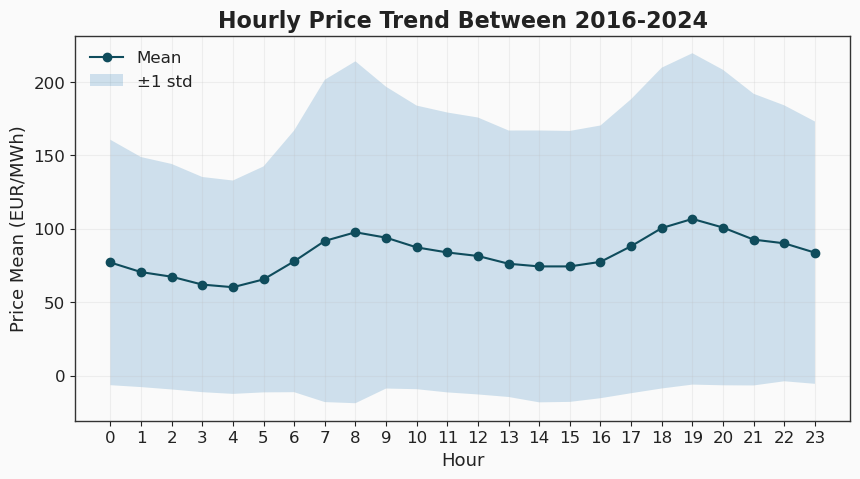

In [8]:
hourly_price = df_alls.groupby(df_alls.index.hour)["Day-ahead Price (EUR/MWh)"].agg(
    hourly_mean = "mean",
    hourly_std = "std"
)

plt.figure()
plt.plot(hourly_price.index, hourly_price["hourly_mean"], marker = "o", label = "Mean", color = style.COLORS["primary"])
plt.fill_between(hourly_price.index, 
                 hourly_price["hourly_mean"] - hourly_price["hourly_std"],
                 hourly_price["hourly_mean"] + hourly_price["hourly_std"],
                 alpha = 0.2, label = "±1 std")
plt.xticks(range(0, 24))
plt.xlabel("Hour")
plt.ylabel("Price Mean (EUR/MWh)")
plt.title("Hourly Price Trend Between 2016-2024")
plt.legend()
plt.savefig("../reports/figures/Hourly_avg_price.png")
plt.show()

**Intraday Pattern** 
- The highest average price occurs at 19:00, representing the residential evening peak coinciding with solar dropping and industrial demand still partially active.
- The second highest peak occurs at 08:00, corresponding to the morning demand ramp-up by the activation of industry, commerical and offices in the morning. 
- The STD of the hourly price show increases at these rush hours as well.

### Weekly Patterns

In [13]:
weekday_mean = df_alls.groupby(df_alls.index.weekday)["Day-ahead Price (EUR/MWh)"].agg(
    day_mean = "mean",
    day_std = "std"
).reset_index().rename(columns = {"timestamp": "weekday"})

weekday_map = {0: "Monday",
               1: "Tuesday",
               2: "Wednesday",
               3: "Thursday",
               4: "Friday", 
               5: "Saturday",
               6: "Sunday"}

weekday_mean["weekday"] = weekday_mean["weekday"].map(weekday_map)
weekday_mean

,weekday,day_mean,day_std
0,Monday,85.627520,102.388626
1,Tuesday,90.629831,102.446332
2,Wednesday,90.356288,101.778728
3,Thursday,89.817034,100.172066
4,Friday,87.125400,95.650583
5,Saturday,72.426141,81.392916
6,Sunday,62.061757,75.282326


In [14]:
print("Weekday mean", np.mean(weekday_mean["day_mean"][0:5]))
print("Weekend mean", np.mean(weekday_mean["day_mean"][5:7]))

Weekday mean 88.71121453409246
Weekend mean 67.2439490248227


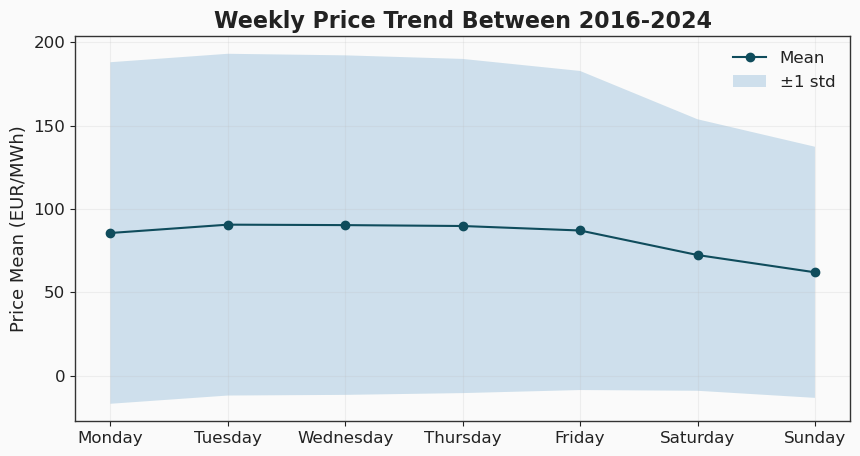

In [ ]:
plt.figure()
plt.plot(weekday_mean["weekday"], weekday_mean["day_mean"], marker = "o", label = "Mean", color = style.COLORS["primary"])
plt.fill_between(weekday_mean["weekday"], 
                 weekday_mean["day_mean"] - weekday_mean["day_std"],
                 weekday_mean["day_mean"] + weekday_mean["day_std"],
                 alpha = 0.2, label = "±1 std")
plt.xlabel("")
plt.ylabel("Price Mean (EUR/MWh)")
plt.title("Weekly Price Trend Between 2016-2024")
plt.legend()
plt.show()

Prices are generally lower on weekends, reflecting reduced industrial activity. The price mean on weekdays is 89 EUR/MWh while on weekends the price mean drops to 67 EUR/MWh. This pattern directly explains why negative prices concentrate on Sundays, as analysed in notebook 04.

### Seasonal Patterns

In [20]:
monthly_mean = df_alls.groupby(df_alls.index.month)["Day-ahead Price (EUR/MWh)"].agg(
    monthly_mean = "mean",
    monthly_std = "std"
).reset_index().rename(columns = {"timestamp": "month"})

month_map = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}
monthly_mean["month"] = monthly_mean["month"].map(month_map)
monthly_mean

,month,monthly_mean,monthly_std
0,Jan,80.590414,63.874418
1,Feb,70.701395,57.243319
2,Mar,75.494561,88.736796
3,Apr,64.020304,84.800087
4,May,55.824885,57.428048
5,Jun,67.653202,75.327433
6,Jul,87.905281,121.124354
7,Aug,100.608672,150.373842
8,Sep,98.825407,117.954430
9,Oct,82.730294,66.029956


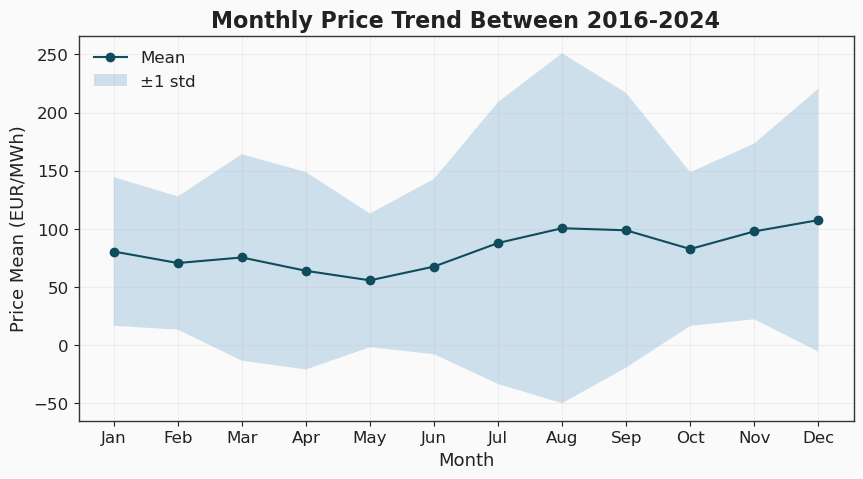

In [23]:
plt.figure()
plt.plot(monthly_mean["month"], monthly_mean["monthly_mean"], marker = "o", label = "Mean", color = style.COLORS["primary"])
plt.fill_between(monthly_mean["month"], 
                 monthly_mean["monthly_mean"] - monthly_mean["monthly_std"],
                 monthly_mean["monthly_mean"] + monthly_mean["monthly_std"],
                 alpha = 0.2, label = "±1 std")
plt.xlabel("Month")
plt.ylabel("Price Mean (EUR/MWh)")
plt.title("Monthly Price Trend Between 2016-2024")
plt.legend()
plt.savefig("../reports/figures/Monthly_avg_price.png")
plt.show()

Winter months exhibit significantly higher prices (~30–40% higher), likely driven by heating demand and lower solar production.

### Yearly Patterns

In [24]:
yearly_mean = df_alls.groupby(df_alls.index.year)["Day-ahead Price (EUR/MWh)"].agg(
    yearly_mean = "mean",
    yearly_std = "std"
).reset_index().rename(columns = {"timestamp": "year"})
yearly_mean

,year,yearly_mean,yearly_std
0,2016,36.748941,24.439543
1,2017,44.965311,20.226933
2,2018,50.198485,18.456753
3,2019,39.449507,14.022041
4,2020,32.203133,16.106854
5,2021,109.171356,84.316099
6,2022,275.878425,145.825722
7,2023,96.855878,45.532279
8,2024,58.018068,40.660032


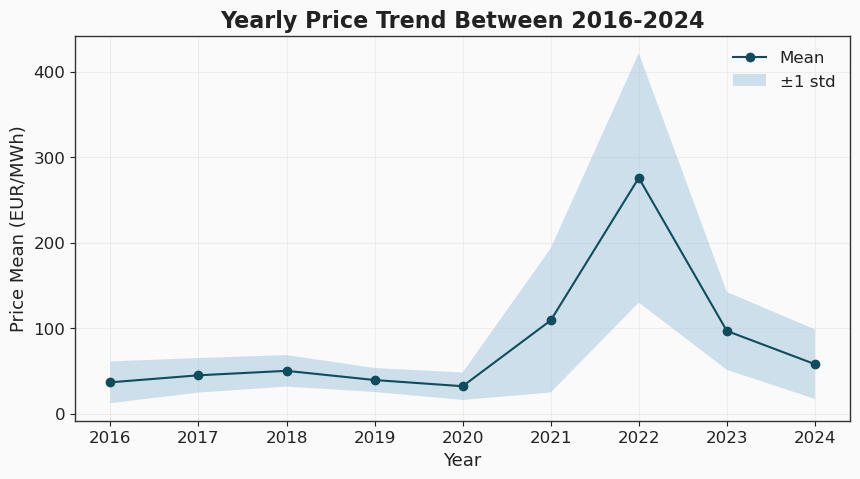

In [26]:
plt.figure()
plt.plot(yearly_mean["year"], yearly_mean["yearly_mean"], marker = "o", label = "Mean", color = style.COLORS["primary"])
plt.fill_between(yearly_mean["year"], 
                 yearly_mean["yearly_mean"] - yearly_mean["yearly_std"],
                 yearly_mean["yearly_mean"] + yearly_mean["yearly_std"],
                 alpha = 0.2, label = "±1 std")
plt.xlabel("Year")
plt.ylabel("Price Mean (EUR/MWh)")
plt.title("Yearly Price Trend Between 2016-2024")
plt.legend()
plt.savefig("../reports/figures/Yearly_avg_price.png")
plt.show()

A strong structural shift is visible across years:

- 2020 shows a dip in average prices, likely linked to reduced economic activity during COVID.
- 2021 marks a strong rebound.
- 2022 exhibits an extreme surge, with average prices more than 2.5× higher than in 2021.
- 2023 returns closer to historical norms.
- 2024 shows a further decline.

The magnitude of the 2022 increase indicates a structural market disruption rather than normal cyclical variation. The normalization in 2023–2024 suggests partial market stabilization.

## Autocorrelation Analysis

In [15]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

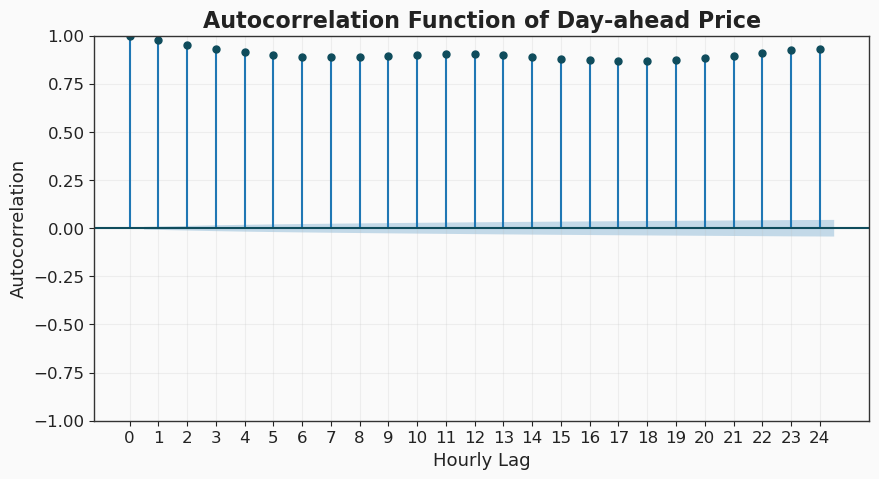

In [36]:
price_series = pd.Series(df_alls["Day-ahead Price (EUR/MWh)"])
fig, ax = plt.subplots(figsize = (10, 5))
plot_acf(price_series, lags = 24, ax = ax, color = style.COLORS["primary"])
ax.set_xlabel("Hourly Lag")
ax.set_xticks(range(0,25))
ax.set_ylabel("Autocorrelation")
ax.set_title("Autocorrelation Function of Day-ahead Price")
plt.show()

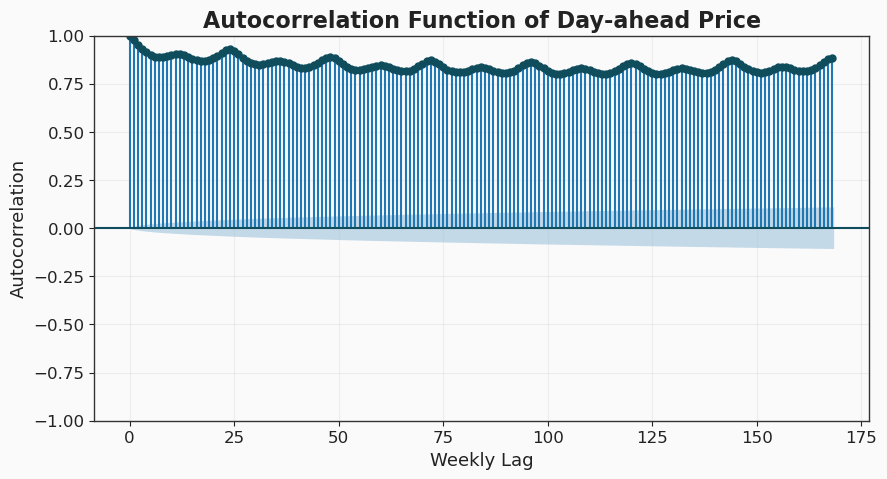

In [37]:
fig, ax = plt.subplots()
plot_acf(price_series, lags = 168, ax = ax, color = style.COLORS["primary"])
ax.set_xlabel("Weekly Lag")
ax.set_ylabel("Autocorrelation")
ax.set_title("Autocorrelation Function of Day-ahead Price")
plt.show()

The ACF reveals strong persistence in the price series, with correlations remaining similar across short lags, indicating non-stationary behavior. In addition, a clear periodic structure is observed, with repeating patterns at lags of 168, corresponding to the weekly seasonality.

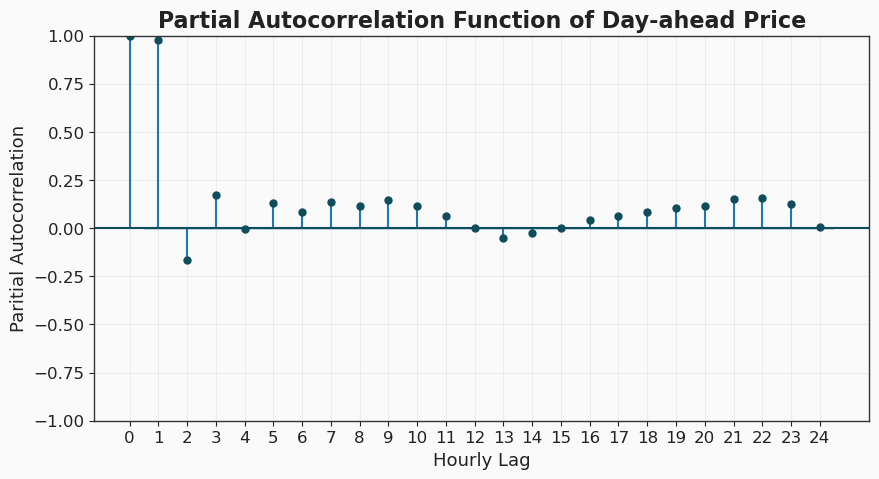

In [45]:
fig, ax = plt.subplots()
plot_pacf(price_series, lags = 24, ax = ax, color = style.COLORS["primary"])
ax.set_xlabel("Hourly Lag")
ax.set_xticks(range(0,25))
ax.set_ylabel("Paritial Autocorrelation")
ax.set_title("Partial Autocorrelation Function of Day-ahead Price")
plt.show()

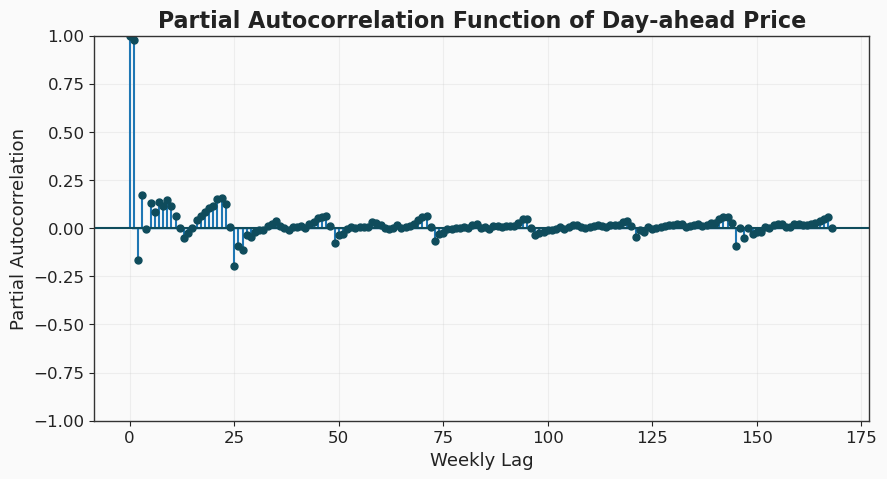

In [47]:
fig, ax = plt.subplots()
plot_pacf(price_series, lags = 168, ax = ax, color = style.COLORS["primary"])
ax.set_xlabel("Weekly Lag")
ax.set_ylabel("Partial Autocorrelation")
ax.set_title("Partial Autocorrelation Function of Day-ahead Price")
plt.show()

The PACF shows significant spikes at lags 1 and 2, suggesting that short-term dynamics are primarily driven by the most recent observations. Beyond these lags, partial correlations diminish rapidly, indicating limited direct influence from more distant past values.

The ACF/PACF observations suggest first-order differencing price series to remove trend and better understanding the price structure.

#### Differenced ACF/PACF 

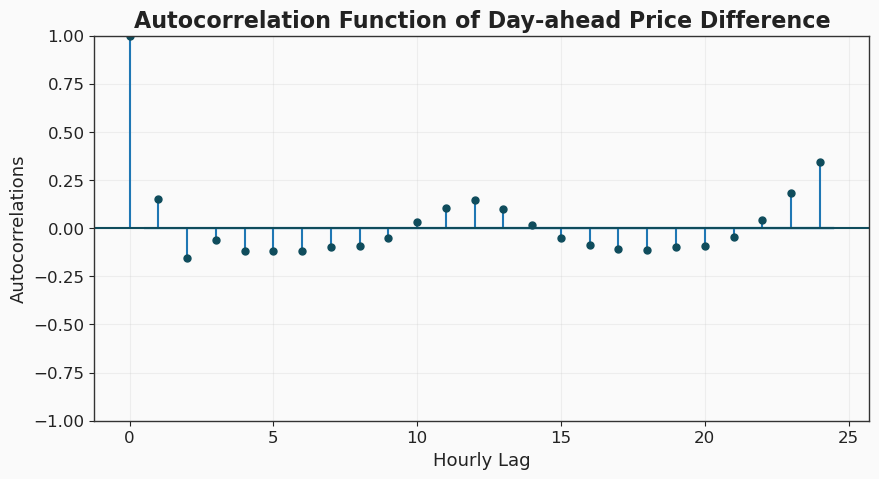

In [67]:
price_diff = price_series.diff().dropna()
fig, ax = plt.subplots()
plot_acf(price_diff, lags = 24, ax = ax, color = style.COLORS["primary"])
ax.set_xlabel("Hourly Lag")
ax.set_ylabel("Autocorrelations")
ax.set_title("Autocorrelation Function of Day-ahead Price Difference")
plt.show()

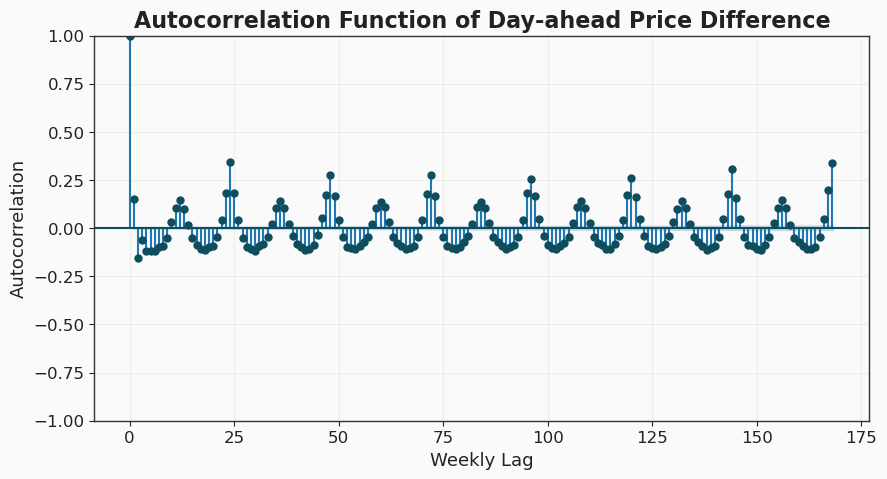

In [49]:
fig, ax = plt.subplots()
plot_acf(price_diff, lags = 168, ax = ax, color = style.COLORS["primary"])
ax.set_xlabel("Weekly Lag")
ax.set_ylabel("Autocorrelation")
ax.set_title("Autocorrelation Function of Day-ahead Price Difference")
plt.show()

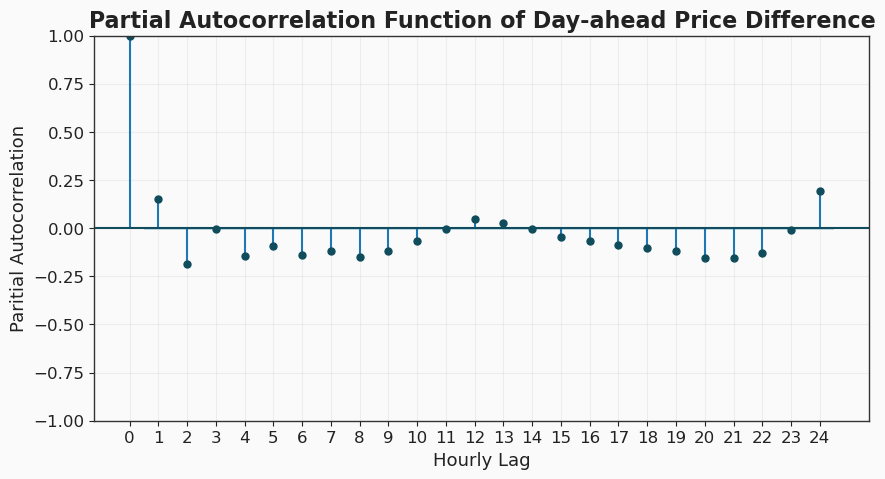

In [50]:
fig, ax = plt.subplots()
plot_pacf(price_diff, lags = 24, ax = ax, color = style.COLORS["primary"])
ax.set_xlabel("Hourly Lag")
ax.set_xticks(range(0,25))
ax.set_ylabel("Paritial Autocorrelation")
ax.set_title("Partial Autocorrelation Function of Day-ahead Price Difference")
plt.show()

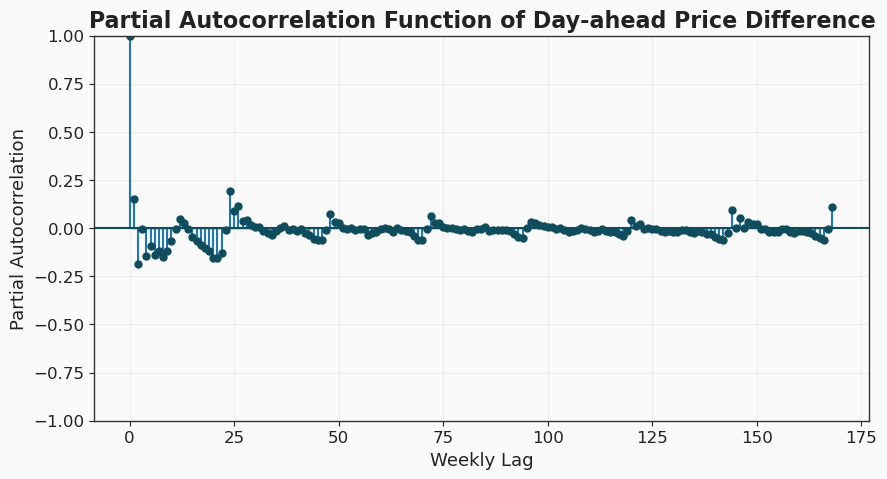

In [51]:
fig, ax = plt.subplots()
plot_pacf(price_diff, lags = 168, ax = ax, color = style.COLORS["primary"])
ax.set_xlabel("Weekly Lag")
ax.set_ylabel("Partial Autocorrelation")
ax.set_title("Partial Autocorrelation Function of Day-ahead Price Difference")
plt.show()

After differencing, the autocorrelation structure becomes more localized, which shows clear daily and weekly seasonalities of the price series. The modelling section should be aware of the non-stationary feature of the price serie. 

## Price Distribution Analysis Regarding 2022 

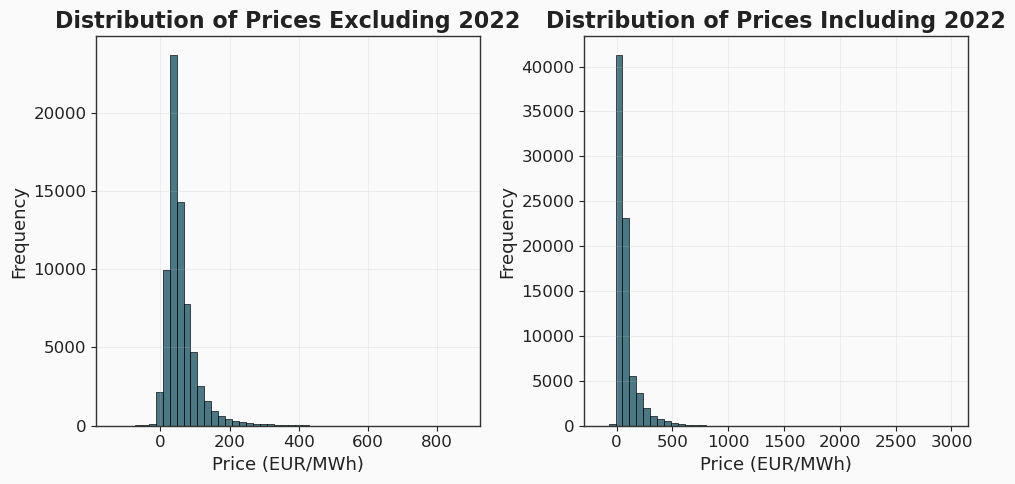

In [44]:
df_no_2022 = df_alls[df_alls.index.year != 2022]

fig, axs = plt.subplots(ncols = 2)
sns.histplot(data = df_no_2022, x = "Day-ahead Price (EUR/MWh)", bins=50, ax = axs[0], color = style.COLORS["primary"])
axs[0].set_title("Distribution of Prices Excluding 2022")
axs[0].set_xlabel("Price (EUR/MWh)")
axs[0].set_ylabel("Frequency")

sns.histplot(data = df_alls, x = "Day-ahead Price (EUR/MWh)", bins=50, ax = axs[1], color = style.COLORS["primary"])
axs[1].set_title("Distribution of Prices Including 2022")
axs[1].set_xlabel("Price (EUR/MWh)")
axs[1].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

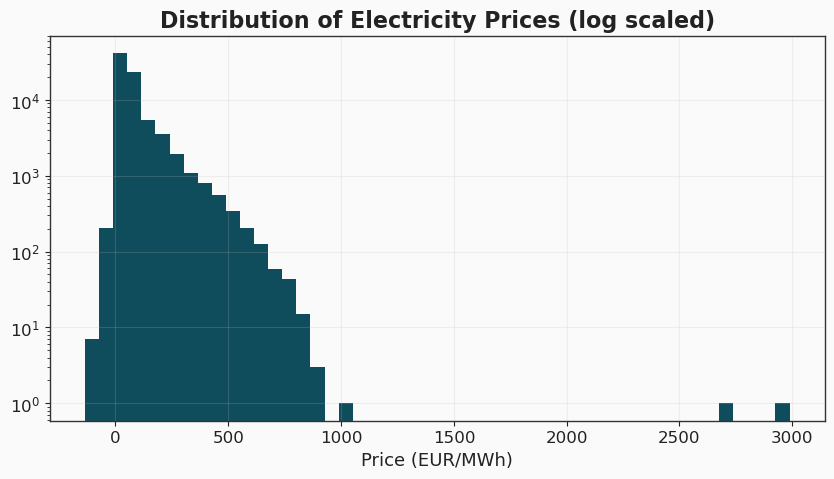

In [41]:
plt.figure()
plt.hist(price_series, bins = 50, color = style.COLORS["primary"])
plt.yscale("log")
plt.xlabel("Price (EUR/MWh)")
plt.title("Distribution of Electricity Prices (log scaled)")
plt.show()

The distribution of price including 2022 shows a stronger right-skewness than the plot excluding 2022. Furthermore, the log scaled distribution plot displayed the few extremely high prices in the dataset. 

Given the strong right-skewness of the price distribution and the presence of extreme values, using RMSE as a loss function would disproportionately weight large errors. Therefore, MAE is considered as a more robust alternative during model training, as it reduces sensitivity to extreme price spikes.

### Rolling statistics

In [26]:
rolling_mean = price_series.rolling(window = 24).mean()
rolling_std = price_series.rolling(window = 24).std()

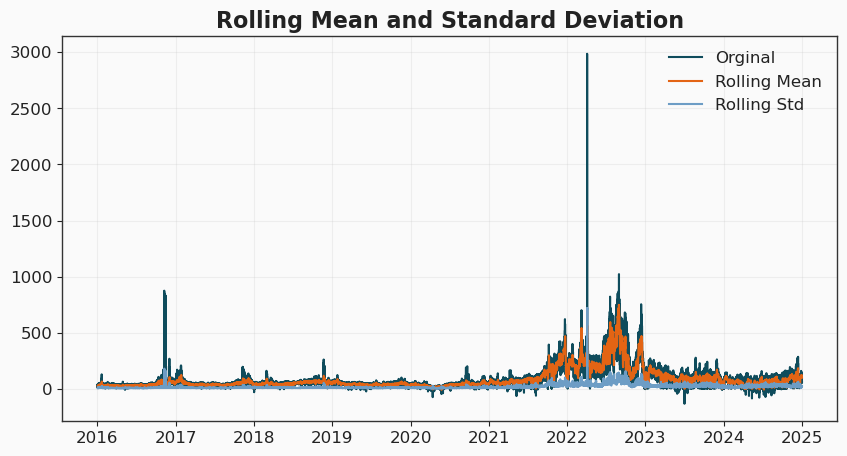

In [55]:
plt.figure()
plt.plot(price_series, label = "Orginal", color = style.COLORS["primary"])
plt.plot(rolling_mean, label = "Rolling Mean", color = style.COLORS["accent"])
plt.plot(rolling_std, label = "Rolling Std", color = style.COLORS["secondary"])
plt.legend()
plt.title("Rolling Mean and Standard Deviation")
plt.show()

Rolling mean changes strongly particularly around year 2022. Rolling std however changes less dramatic except around 2017 and 2022. 

## Augmented Dickey-Fuller (ADF) Test

In [28]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(price_series.dropna())
print("ADF Statistics: ", result[0])
print("p-value: ", result[1])

ADF Statistics:  -6.819785475484844
p-value:  2.015651685014279e-09


In [29]:
result_diff = adfuller(price_diff.dropna())
print("p-value of price difference serie: ", result_diff[1])

p-value of price difference serie:  0.0


ADF test suggests that the price series is stationary despite strong persistence and seasonal dependence. 

## Modelling Recommendations

**Recommended features**
- lag_1
- lag_2
- lag_24
- lag_168
- rolling means
- calendar features

**Recommended loss function**
- MAE preferred over RMSE due to extreme spikes

**Recommended modelling approaches**
- Gradient boosting models
- Seasonal ARIMA baseline
- Quantile forecasting spikes

## Summary
The temporal exploratory analysis reveals that French day-ahead electricity prices exhibit strong multi-scale temporal structure driven by demand cycles, seasonal effects, and market disruptions.

Hourly patterns show pronounced evening peaks associated with residential demand and reduced solar production, while weekly patterns indicate systematically lower weekend prices due to reduced industrial activities. Seasonal patterns further highlights elevated winter prices linked to heating demand and lower renewable generations.

A major structural disruption occurs during the 2022 energy crisis, where price levels and volatility increase dramatically relative to previous years.
Distribution analysis confirms that the inclusion of 2022 introduces strong right-skewness and extreme outliers, which substantially influences the statistical behavior of the dataset.

Autocorrelation analysis reveals strong persistence together with clear daily and weekly periodicity. Significant ACF peaks at lags of 24 and 168 hours motivate the inclusion of seasonal lag features in forecasting models. PACF analysis suggests that short-term dependencies are dominated by the most recent observations, partially lags 1 and 2.

Rolling statistics indicate temporal instability around major market events, especially during 2022. However, the Augmented Dicken-Fuller test rejects unit-root non-stationarity, suggesting that the series remains statistically stationary despite strong persistence and seasonal dependence. 

These observations have direct implications for model design. The presence of extreme price spikes suggests that RMSE-based training objectives may overweight rare crisis events, while MAE-based objectives provide more robust performance across typical operating conditions. Recommended modelling features include short-term lag variables, seasonal lag variables, rolling statistics, and calendar-based temporal features.

Overall, the analysis demonstrates that electricity prices in France are governed by a combination of short-term temporal memory, recurring seasonal cycles, and occasional structural market disruptions. These characteristics should guide both feature engineering and forecasting model selection in subsequent modelling stages.